# Gaussian Subgrains workflow

**Mads Carlsen 16.09.2026**

The goal of this notebook is to demonstrate how to run the workflow for deformed miscrostructures based on gaussian grains with misorientation.
The demonstration closely follows the example in ``README.rst`` file.

In [1]:
import numpy as np
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
import torch

from xrd_simulator.beam import GaussianBeam
from xrd_simulator.detector import Detector
from xrd_simulator.phase import Phase

# Define the beam.
gaussian_beam = GaussianBeam(
    xray_propagation_direction=np.array([1.0, 0.0, 0.0]),
    beam_centroid_position=np.array([0.0, 0.0, 0.0,]),
    wavelength=0.28523,
    polarization_vector = np.array([0.0, 1.0, 0.0,]),
    long_axis_width = 300,
    long_axis_direction=np.array([0.0, 0.0, 1.0,]),
    short_axis_width = 50,
    short_axis_direction=np.array([0.0, 1.0, 0.0,]),
)

# Define a detector
detector = Detector(
   det_corner_0=np.array([142938.3, -38400.0, -38400.0]),
   det_corner_1=np.array([142938.3, 38400.0, -38400.0]),
   det_corner_2=np.array([142938.3, -38400.0, 38400.0]),
   pixel_size=(25.0, 25.0),
   gaussian_sigma=1.0,
   max_gaussian_kernel_radius=5,
)

# Define the crystallographic information
quartz = Phase(
   unit_cell=[4.926, 4.926, 5.4189, 90.0, 90.0, 120.0],
   sgname="P3221",  # (Quartz)
   path_to_cif_file="../tests/data/quartz.cif",  # phases can be defined from crystalographic information files
)


/home/mads/Programming/xrd_simulator_gs/xrd_simulator/detector.py:863: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  G(\sigma_1) \otimes G(\sigma_2)


A subgrain is defined by a 3D gaussian in real space (centroid and shape-matrix), a strain-tensor, and a gaussian in orientation space (a centroid orientation and a misorientation tensor).

For this example we generate random values.

In [2]:
from xrd_simulator.gaussian_crystal_model import GaussianSubgrain, GaussianPolycrystal

# Utility function to generate random symmetric tensors
def make_random_tensor(axis_1, axis_2):
    random_direction = np.random.normal(size=3)
    random_direction = random_direction/np.linalg.norm(random_direction)
    tensor = axis_1**2 * np.eye(3) + (axis_2**2-axis_1**2) * np.outer(random_direction, random_direction)
    return tensor

N_subgrains = 2000

grain_list = []

for ii in range(N_subgrains):

    position = np.random.uniform(-500, 500, size=(3,))
    shape_tensor = misorientation_tensor = make_random_tensor(
        np.random.uniform(200, 50),
        np.random.uniform(200, 50),
    )

    orientation = R.random().as_matrix()
    misorientation_tensor = make_random_tensor(
        np.random.uniform(0.01, 0.03),
        np.random.uniform(0.01, 0.03),
    )

    strain = np.zeros((3, 3,))


    grain = GaussianSubgrain(
        phase=quartz, #  For now it assumes all gaussians are the same phase, but it just needs a wrapper for multiphase
        position=position, # 3 vector centroid real-space position
        shape_tensor=shape_tensor, # 3-by-3 symmetric shape tensor where the eigenvalues are the radii-squared.
        orientation=orientation, # 3-by-3 rotation matrix.
        misorientation_tensor=misorientation_tensor, # 3-by-3 misorientation tensor where the eigenvalues are the misorientaion spread in radians squared.
                                                     # misorientation vectors live in laboratory coordinates.
        strain_tensor=strain # 3-by-3 symmetric strain tensor.
    )

    grain_list.append(grain)
    
gaussian_polycrystal = GaussianPolycrystal(grain_list, max_misorientation=0.03, max_grain_size=200)


In [7]:
# Calculate a diffraction pattern
angle = np.radians(1.0)
axis = np.array([0, 1 / np.sqrt(2), -1 / np.sqrt(2)])

f = gaussian_polycrystal.diffract(
    beam=gaussian_beam,
    detector=detector,
    sample_translation=np.array([0.0, 0.0, 0.0,]),    
    sample_orientation=R.from_rotvec(0.5*axis * angle).as_matrix(),
    sample_rotation_during_exposure = 0.5 * axis * angle,
    verbose=True,
    threshold = 10.0,
)
 

Beam-grain intersection took 0.007360935211181641.
Bragg-condition filterin took 1.6927034854888916. (7356000 -> 2848245)
Reciprocal space part took 3.417297601699829
Realspace proj took 0.8181228637695312
Raytracing took 1.768453598022461
Rasterization took 230.5638062953949


/tmp/ipykernel_100936/4267644885.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = axs[0].imshow(np.log10(f+1e-10), cmap="jet", vmax = 6, vmin = 3)
/tmp/ipykernel_100936/4267644885.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = axs[1].imshow(np.log10(f+1e-10), cmap="jet", vmax = 6, vmin = 3)


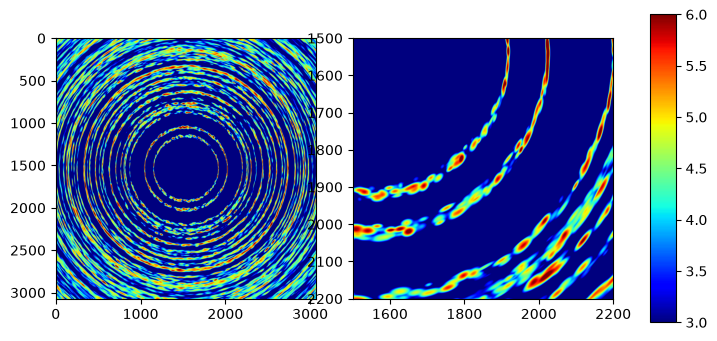

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(8, 4), width_ratios=(1, 1, 0.1))
img = axs[0].imshow(np.log10(f+1e-10), cmap="jet", vmax = 6, vmin = 3)


img = axs[1].imshow(np.log10(f+1e-10), cmap="jet", vmax = 6, vmin = 3)
axs[1].set_xlim(1500, 2200)
axs[1].set_ylim(2200, 1500)
fig.colorbar(img, cax = axs[2])

plt.show()


We can also compute polefigures:

/tmp/ipykernel_100936/2384135197.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


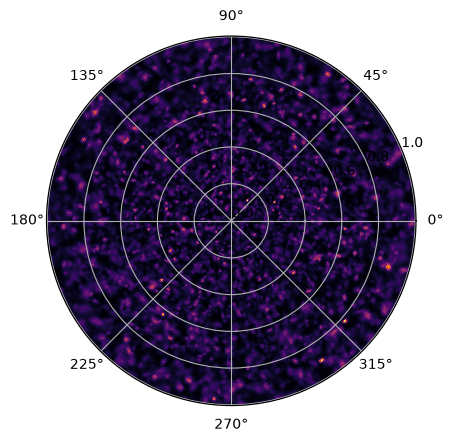

In [11]:
pf, polar_angles, azim_angles = gaussian_polycrystal.render_polefigure((1,2,3), resolution_in_degrees=0.5)

fig = plt.figure()
ax = plt.subplot(1, 1, 1, polar=True)
ax.pcolormesh(azim_angles, np.tan(polar_angles / 2), pf, cmap='inferno')
fig.show()